# Series de Tiempo — Temperatura de Guatemala

Curso: CC3084 · Data Science · Semestre 02, 2026

# Dependencias 

In [4]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, fligner
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

plt.rcParams['figure.figsize']=(11,4.5)
plt.rcParams['axes.grid']=True


# Ejercicio 1 
Cargue el archivo con R o con Python y explórelo un poco, ¿Cuáles son los extremos de la temperatura promedio de la tierra? ¿y por capa? ¿Como ha sido la tendencia, ha bajado, subido, se ha mantenido constante alrededor de un valor?

Datos: (918, 10) Rango: 1950-01-01 a 2026-06-01
Faltantes: 0 Duplicados: 0

EJERCICIO 1: EXTREMOS Y TENDENCIA
                                min   fecha_min      max   fecha_max    media  \
variable                                                                        
dewpoint_2m_c               14.1987  1951-02-01  21.9597  2024-09-01  18.7362   
temperature_2m_c            18.9701  1956-01-01  28.6864  2024-05-01  23.0502   
skin_temperature_c          19.1458  1956-01-01  29.7363  2024-05-01  23.4438   
soil_temperature_layer_1_c  19.8376  1956-01-01  30.2933  2024-05-01  24.0962   
soil_temperature_layer_2_c  19.9601  1956-01-01  29.8042  2024-05-01  24.0665   
soil_temperature_layer_3_c  20.4869  1956-01-01  28.3469  2024-05-01  24.0106   
soil_temperature_layer_4_c  21.5669  1976-02-01  26.8766  2024-06-01  23.9609   

                            pendiente_C_decada  p_tendencia  
variable                                                     
dewpoint_2m_c                       

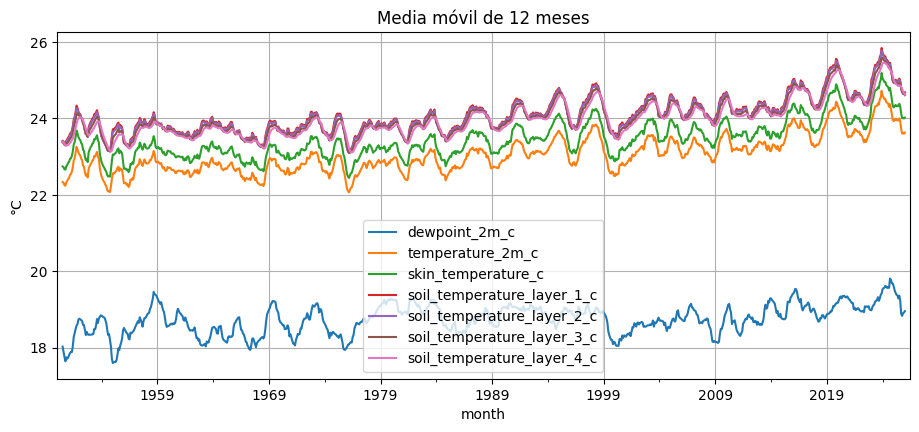

In [5]:

paths=[Path('../data/raw/guatemala_temperatura.csv'),Path('01_series_tiempo/data/raw/guatemala_temperatura.csv')]
path=next((p for p in paths if p.exists()),None)
if path is None: raise FileNotFoundError('No se encontró guatemala_temperatura.csv')
df=pd.read_csv(path,parse_dates=['month']).sort_values('month')
ts=df.set_index('month').asfreq('MS')
print('Datos:',df.shape,'Rango:',df.month.min().date(),'a',df.month.max().date())
print('Faltantes:',int(df.isna().sum().sum()),'Duplicados:',int(df.month.duplicated().sum()))

print('\nEJERCICIO 1: EXTREMOS Y TENDENCIA')
cols=[c for c in df.columns if c.endswith('_c')]
rows=[]; x=np.arange(len(df))
for c in cols:
    imin,imax=df[c].idxmin(),df[c].idxmax(); reg=linregress(x,df[c])
    rows.append({'variable':c,'min':df.loc[imin,c],'fecha_min':df.loc[imin,'month'].date(),'max':df.loc[imax,c],'fecha_max':df.loc[imax,'month'].date(),'media':df[c].mean(),'pendiente_C_decada':reg.slope*120,'p_tendencia':reg.pvalue})
summary=pd.DataFrame(rows).set_index('variable')
print(summary.round(4))
ts[cols].rolling(12,center=True).mean().plot(title='Media móvil de 12 meses'); plt.ylabel('°C'); plt.show()

In [8]:
# Extremos, promedio y rango de todas las variables medidas en °C
variables_temperatura = [
    columna for columna in df.columns
    if columna.endswith("_c")
]

resumen = (
    df[variables_temperatura]
    .agg(["min", "max", "mean"])
    .T
    .round(2)
)

# El rango indica cuánto varió cada variable entre su mínimo y máximo
resumen["rango"] = (
    resumen["max"] - resumen["min"]
).round(2)

resumen

,min,max,mean,rango
dewpoint_2m_c,14.20,21.96,18.74,7.76
temperature_2m_c,18.97,28.69,23.05,9.72
skin_temperature_c,19.15,29.74,23.44,10.59
soil_temperature_layer_1_c,19.84,30.29,24.10,10.45
soil_temperature_layer_2_c,19.96,29.80,24.07,9.84
soil_temperature_layer_3_c,20.49,28.35,24.01,7.86
soil_temperature_layer_4_c,21.57,26.88,23.96,5.31


In [9]:
# Seleccionar únicamente las cuatro capas del suelo
capas_suelo = [
    columna for columna in df.columns
    if columna.startswith("soil_temperature_layer")
]

resumen_capas = (
    df[capas_suelo]
    .agg(["min", "max", "mean"])
    .T
    .round(2)
)

resumen_capas["rango"] = (
    resumen_capas["max"] - resumen_capas["min"]
).round(2)

resumen_capas

,min,max,mean,rango
soil_temperature_layer_1_c,19.84,30.29,24.10,10.45
soil_temperature_layer_2_c,19.96,29.80,24.07,9.84
soil_temperature_layer_3_c,20.49,28.35,24.01,7.86
soil_temperature_layer_4_c,21.57,26.88,23.96,5.31


In [10]:
# Fechas en las que ocurrió el mínimo y el máximo de cada variable
fechas_extremos = pd.DataFrame({
    "fecha_min": df[variables_temperatura].idxmin(),
    "fecha_max": df[variables_temperatura].idxmax()
})

fechas_extremos

,fecha_min,fecha_max
dewpoint_2m_c,13,896
temperature_2m_c,72,892
skin_temperature_c,72,892
soil_temperature_layer_1_c,72,892
soil_temperature_layer_2_c,72,892
soil_temperature_layer_3_c,72,892
soil_temperature_layer_4_c,313,893


Por medio de estos resultados podemos ver que 

1. Extremos de temperatura promedio de la tierra: 
   - Mínima: 18.97°C
   - Máxima: 28.69°C
   - Media: 23.05°C
   Por lo tanto se pudo observar un rango de 9.72°C entre la temperatura mínima y máxima y su promedio durante todo el periodo de tiempo analizado fue de 23.05°C.

2. Extremos por Capa
   Entre las capas del suelo, la capa 1 alcanzó la temperatura máxima más alta con 30.29°C, mientras que la capa 4 tuvo la temperatura mínima o sea la más profunda o más baja con 5.31°C. Esto indica que las capas del suelo tienen diferentes comportamientos térmicos, siendo la capa 1 más propensa a cambios y la capa 4 más estable.

3. Tendencia 
   La tendencia general ha sido levemente creciente, todas las variables presentan una pendiente positiva lo que indica que la temperatura del aire a dos metros ha aumentado a lo largo del tiempo. Las temperaturas de la superficie y capas del suelo también aumentaron entre 0.16°C y 0.17°C por año, lo que sugiere un calentamiento gradual en la región durante el período analizado.

4. Análisis
   Se podría decir que la temperatura no ha bajao ni se ha mantenido constante, aunque sí existen fluctuaciones estacionales durante el año, la tendencia en general sí se mantiene en un aumento de temperatura. 



# Ejercicio 2
Divida el conjunto en entrenamiento y prueba. Deje los últimos 36 meses para probar.


EJERCICIOS 2 Y 3: TRAIN/TEST Y ESTACIONARIEDAD
Cantidad total de observaciones: 918
Fecha inicial: 0
Fecha final: 917
ENTRENAMIENTO
Observaciones: 882
Periodo: 0 a 881

PRUEBA
Observaciones: 36
Periodo: 882 a 917
La división se realizó correctamente.


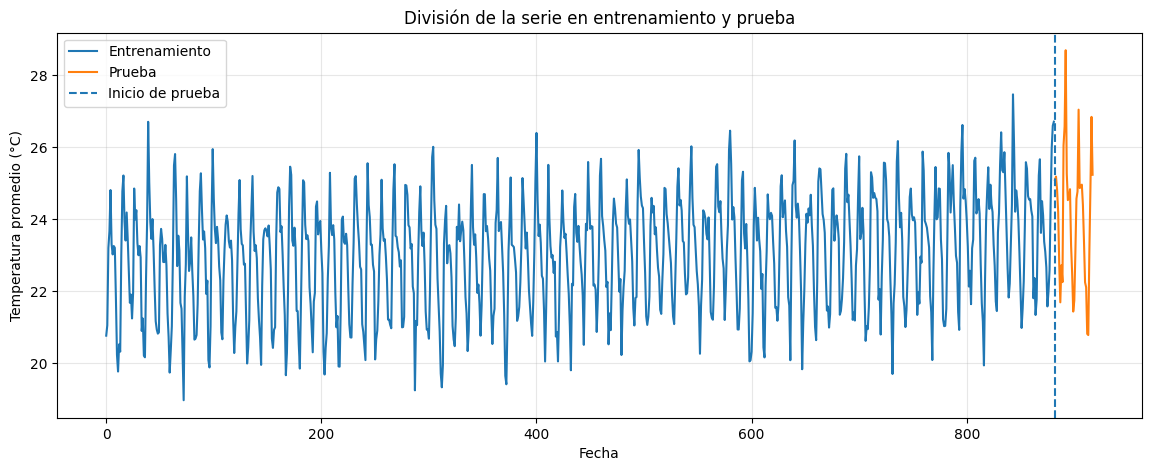

In [13]:

print('\nEJERCICIOS 2 Y 3: TRAIN/TEST Y ESTACIONARIEDAD')
# Serie principal que se utilizará para el análisis y los modelos
serie = df["temperature_2m_c"].astype(float).copy()

print("Cantidad total de observaciones:", len(serie))
print("Fecha inicial:", serie.index.min())
print("Fecha final:", serie.index.max())

# Reservar los últimos 36 meses para evaluar los modelos
n_prueba = 36

train = serie.iloc[:-n_prueba].copy()
test = serie.iloc[-n_prueba:].copy()

print("ENTRENAMIENTO")
print("Observaciones:", len(train))
print("Periodo:", train.index.min(), "a", train.index.max())

print("\nPRUEBA")
print("Observaciones:", len(test))
print("Periodo:", test.index.min(), "a", test.index.max())
# Verificar que el conjunto de prueba tenga exactamente 36 meses
assert len(test) == 36

# Verificar que entrenamiento y prueba no se traslapen
assert train.index.max() < test.index.min()

print("La división se realizó correctamente.")
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    train.index,
    train,
    label="Entrenamiento"
)

plt.plot(
    test.index,
    test,
    label="Prueba"
)

plt.axvline(
    test.index.min(),
    linestyle="--",
    label="Inicio de prueba"
)

plt.title("División de la serie en entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Temperatura promedio (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Se reservaron los últimos 36 meses para el conjunto de prueba. Por lo
tanto, el conjunto de entrenamiento contiene 882 observaciones desde
enero de 1950 hasta junio de 2023, mientras que el conjunto de prueba
abarca desde julio de 2023 hasta junio de 2026.

Los datos no se mezclaron aleatoriamente, debido a que en una serie de
tiempo debe conservarse el orden cronológico. El modelo se entrenará
únicamente con información del pasado y posteriormente se evaluará su
capacidad para predecir los 36 meses más recientes.

# Ejercicio 3 
 Conviértalo en una serie de tiempo y analícela (explique sus razonamientos), para esto:
- Explore la serie, descompóngala en componentes y analícelos
- Determine si tiene tendencia
- Determine si es estacionaria, recuerde que debe ser estacionaria en media y en varianza.

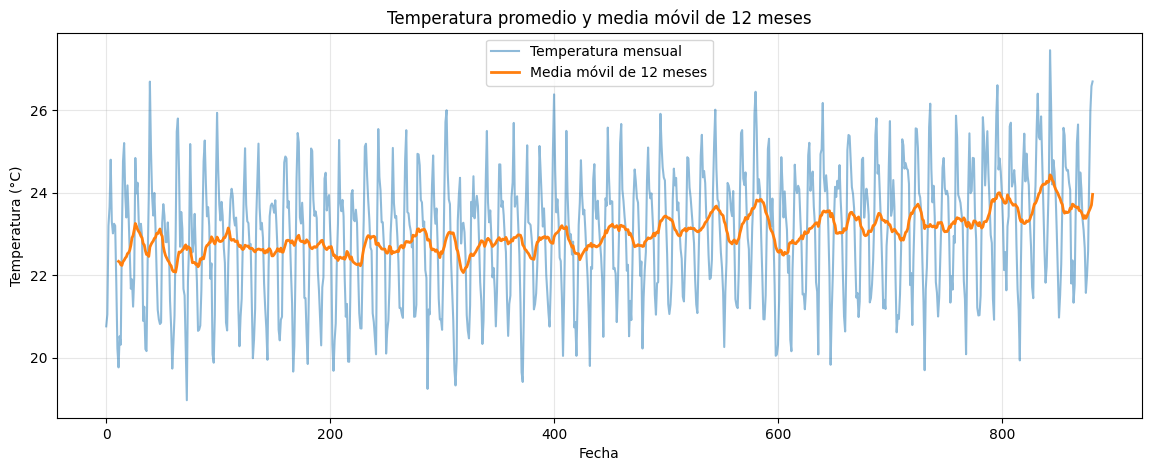

In [14]:
# Media y desviación estándar móviles de 12 meses
media_movil = train.rolling(window=12).mean()
desviacion_movil = train.rolling(window=12).std()

plt.figure(figsize=(14, 5))

plt.plot(
    train.index,
    train,
    alpha=0.5,
    label="Temperatura mensual"
)

plt.plot(
    media_movil.index,
    media_movil,
    linewidth=2,
    label="Media móvil de 12 meses"
)

plt.title("Temperatura promedio y media móvil de 12 meses")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Podemos ver que la temperatura mensual tiene sube y bajas constantes y estas se repiten cada año, lo que indica que la serie tiene un patrón estacional. Además, se observa una tendencia creciente a lo largo del tiempo, lo que sugiere que la temperatura promedio ha aumentado en los últimos años.
En cambio la media móvil elimina parte de esa variación mensual y podemos observar mejor que la temperatura promedio ha aumentado a lo largo del tiempo.

In [16]:
# Promedio histórico de temperatura para cada mes
perfil_mensual = train.groupby(train.index.month).mean()

nombres_meses = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

perfil_mensual.index = nombres_meses

perfil_mensual.round(2)

AttributeError: 'RangeIndex' object has no attribute 'month'

In [17]:
plt.figure(figsize=(11, 5))

plt.plot(
    perfil_mensual.index,
    perfil_mensual.values,
    marker="o"
)

plt.title("Temperatura promedio histórica por mes")
plt.xlabel("Mes")
plt.ylabel("Temperatura promedio (°C)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

NameError: name 'perfil_mensual' is not defined

<Figure size 1100x500 with 0 Axes>

# Ejercicio 4 
Haga modelos de predicción usando alguno de los modelos ARIMA (AR, MA, ARIMA o SARIMA)
- Transforme la serie para lograr que sea estacionaria en media y en varianza en caso de que no lo
fuera.
- Verifique que las transformaciones lograron hacerla estacionaria en media, si no es así aplique otra
diferenciación y verifique nuevamente.
- Estime los parámetros del modelo. Utilice las funciones de autocorrelación y de autocorrelación
parcial para esto.
- Entrene el modelo con los parámetros estimados y el conjunto de entrenamiento.
- Haga 2 modelos más, puede usar el autoarima de R si trabaja en R. Entrénelos con el conjunto de
entrenamiento


EJERCICIO 4: ACF/PACF Y MODELOS


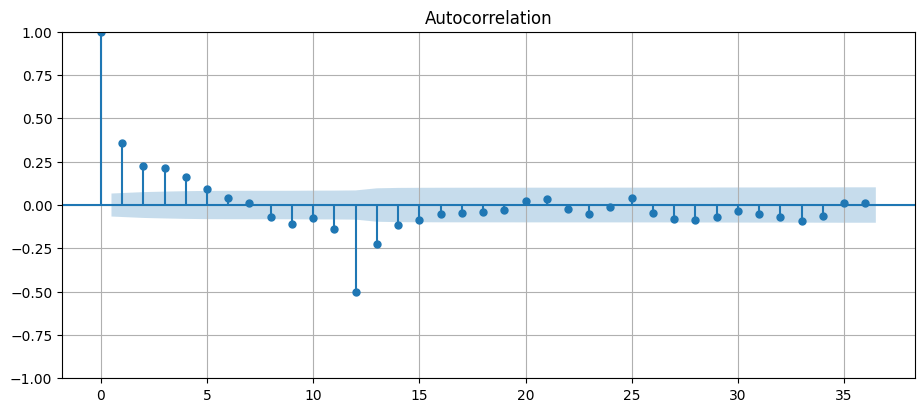

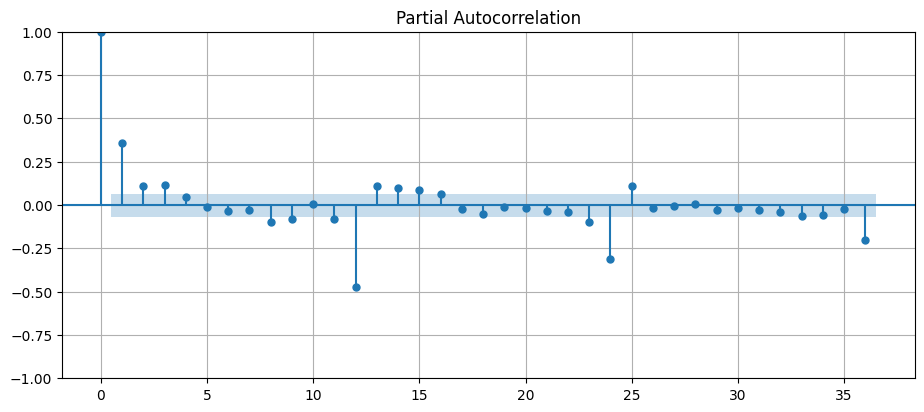

In [18]:

print('\nEJERCICIO 4: ACF/PACF Y MODELOS')
d12=train.diff(12).dropna(); plot_acf(d12,lags=36); plt.show(); plot_pacf(d12,lags=36,method='ywm'); plt.show()
specs={
'SARIMA(1,0,1)(0,1,1,12)':((1,0,1),(0,1,1,12)),
'SARIMA(1,0,2)(0,1,1,12)':((1,0,2),(0,1,1,12)),
'SARIMA(2,0,1)(0,1,1,12)':((2,0,1),(0,1,1,12))}
fits={n:SARIMAX(train,order=o,seasonal_order=s,trend='c',enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=300) for n,(o,s) in specs.items()}


# Ejercicio 5
valide uno los modelos. Analice:

- Contrastes sobre los coeficientes: Significación y raíces comunes.
- Diagnóstico: Este análisis se basa habitualmente en los residuos que no deben estar correlacionados con el
pasado: su correlograma no debe tener ninguna correlación significativamente distinta de cero.
- Contrastes respecto a modelos alternativos: Métricas AIC y BIC

In [19]:
print('\nEJERCICIO 5: VALIDACIÓN')
rows=[]
for n,r in fits.items():
    burn=max(r.loglikelihood_burn,24); resid=pd.Series(r.resid).iloc[burn:].dropna()
    lb=acorr_ljungbox(resid,lags=[12,24],model_df=max(len(r.params)-1,0),return_df=True)
    rows.append({'modelo':n,'AIC':r.aic,'BIC':r.bic,'LB_p12':lb.loc[12,'lb_pvalue'],'LB_p24':lb.loc[24,'lb_pvalue']})
comparison=pd.DataFrame(rows).sort_values('AIC'); print(comparison.round(4))
best_name='SARIMA(1,0,1)(0,1,1,12)'; best=fits[best_name]
print('\nCoeficientes del mejor modelo:'); print(pd.DataFrame({'coef':best.params,'p':best.pvalues}).round(5))



EJERCICIO 5: VALIDACIÓN
                    modelo        AIC        BIC  LB_p12  LB_p24
0  SARIMA(1,0,1)(0,1,1,12)  1403.8626  1427.6240  0.4153  0.6366
1  SARIMA(1,0,2)(0,1,1,12)  1404.5629  1433.0695  0.3717  0.5558
2  SARIMA(2,0,1)(0,1,1,12)  1433.1999  1461.7135  0.0004  0.0123

Coeficientes del mejor modelo:
              coef        p
intercept  0.00376  0.00062
ar.L1      0.76651  0.00000
ma.L1     -0.50234  0.00000
ma.S.L12  -0.95630  0.00000
sigma2     0.29084  0.00000


# Ejercicio 6 
Haga una predicción usando el conjunto de prueba, y el mejor modelo determinado en el ejercicio anterior.


In [ ]:
print('\nEJERCICIO 6: PRONÓSTICO')
def metrics(y,p):
    y=np.asarray(y); p=np.asarray(p)
    return {'MAE':mean_absolute_error(y,p),'RMSE':mean_squared_error(y,p)**0.5,'MAPE_%':np.mean(np.abs((y-p)/y))*100}
fc=best.get_forecast(len(test)); pred=fc.predicted_mean; pred.index=test.index; ci=fc.conf_int(); ci.index=test.index
print(best_name,metrics(test,pred))
ax=train.iloc[-120:].plot(label='train'); test.plot(ax=ax,label='real'); pred.plot(ax=ax,label='SARIMA'); ax.fill_between(test.index,ci.iloc[:,0],ci.iloc[:,1],alpha=.2); ax.legend(); plt.show()

# Ejercicio 7 
Utilice otros modelos para predecir (holt winters, suavizamiento exponencial y seasonal naive).
Compare resultados.

In [ ]:
print('\nEJERCICIO 7: OTROS MODELOS')
hw=ExponentialSmoothing(train,trend='add',seasonal='add',seasonal_periods=12,initialization_method='estimated').fit(); p_hw=hw.forecast(len(test)); p_hw.index=test.index
ses=SimpleExpSmoothing(train,initialization_method='estimated').fit(); p_ses=ses.forecast(len(test)); p_ses.index=test.index
p_naive=pd.Series(np.resize(train.iloc[-12:].to_numpy(),len(test)),index=test.index)
preds={best_name:pred,'Holt-Winters':p_hw,'Suavizamiento simple':p_ses,'Naive estacional':p_naive}
result=pd.DataFrame([{'modelo':n,**metrics(test,p)} for n,p in preds.items()]).sort_values('RMSE'); print(result.round(4))

# Ejercicio 8 
Determine si su modelo es capaz de predecir valores actuales.

In [ ]:
print('\nEJERCICIO 8: CONCLUSIÓN')
coverage=((test>=ci.iloc[:,0])&(test<=ci.iloc[:,1])).mean()*100
print('Cobertura intervalo 95%:',round(coverage,2),'%')
print('El modelo es útil para promedios mensuales si RMSE<1 °C y MAPE<5%; no predice valores diarios ni extremos.')
order,seasonal=specs[best_name]
final=SARIMAX(series,order=order,seasonal_order=seasonal,trend='c',enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=300)
f=final.get_forecast(12)
future=pd.DataFrame({'pronostico_C':f.predicted_mean,'inferior_95':f.conf_int().iloc[:,0],'superior_95':f.conf_int().iloc[:,1]})
print('\nPronóstico 12 meses posteriores:'); print(future.round(3))